In [1]:
from Scripts import ScriptOptions
import os

PATH_TO_DATASET = r"C:\Users\liali\YoloWdTagger\wdv3-timm\Tests\Normal"


params= ScriptOptions(
    ImageFolder= PATH_TO_DATASET,
    model='big', #Ещё есть convnext, swinv2, big, vit
    gen_threshold=0.35, #увереность для общей картинки/и если не установлено значение в конфиге yolo моделей то для них тоже
    char_threshold=0.75, # Увереность для персонажей, теги персонажей берутся только из полной области, по причине я так захотел
    batch=2,
    recursive=False,
    save_txt=False,
    append_txt=False,
    add_tags_before="",
    add_tags_after="",
    remove_tags="",
    detectors_config= "detectors.json"

)



In [2]:
from Scripts import BatchTagging
result=BatchTagging(params)

Файл config.json уже существует в models\taggers\wd-eva02-large-tagger-v3
Файл selected_tags.csv уже существует в models\taggers\wd-eva02-large-tagger-v3
Загрузка модели тегирования 'big' из 'SmilingWolf/wd-eva02-large-tagger-v3'...
Loading model from models\taggers\wd-eva02-large-tagger-v3\model.safetensors using safetensors
Загрузка списка тегов...
Загрузка тегов из локального файла: models\taggers\wd-eva02-large-tagger-v3\selected_tags.csv
Создание трансформации данных...
Загрузка конфигурации детекторов из detectors.json...
Загрузка модели YOLO person_yolov8s-seg.pt...
Loading YOLO model from local directory: models\yolo\person_yolov8s-seg.pt
Загрузка модели YOLO face_yolov9c.pt...
Loading YOLO model from local directory: models\yolo\face_yolov9c.pt
Всего изображений для обработки: 37

Обработка изображения 1/37: C:\Users\liali\YoloWdTagger\wdv3-timm\Tests\Normal\(43).jpg

image 1/1 C:\Users\liali\YoloWdTagger\wdv3-timm\Tests\Normal\(43).jpg: 384x640 (no detections), 138.6ms
Speed:

In [3]:
# result[0][x] - теги по областям, для общей области, путь до изображения, какие детекторы и box для них Для Изображения X
# result[1][x] - обьедененые теги + путь до изображения X
print(result[1][0].keys())
print()
print(result[0][0].keys())
print()
print(result[1][0]['merged_tags'].keys())

dict_keys(['image_path', 'merged_tags'])

dict_keys(['image_path', 'full_image', 'detectors'])

dict_keys(['caption', 'taglist', 'general', 'character', 'ratings'])


In [4]:
print(result[1][3]['merged_tags']['caption'])
print()
print(result[1][3]['merged_tags']['taglist'])

1boy, 1girl, age_difference, back-to-back, black_hair, blush, blush_stickers, brown_eyes, cat, child, closed_mouth, from_side, grey_hair, hair_bobbles, hair_ornament, japanese_clothes, long_hair, maneki-neko, newspaper, old, old_man, old_woman, one_side_up, open_mouth, profile, short_hair, smile, television, two_side_up, wrinkled_skin

1boy, 1girl, age difference, back-to-back, black hair, blush, blush stickers, brown eyes, cat, child, closed mouth, from side, grey hair, hair bobbles, hair ornament, japanese clothes, long hair, maneki-neko, newspaper, old, old man, old woman, one side up, open mouth, profile, short hair, smile, television, two side up, wrinkled skin


In [5]:
print(result[0][1]['full_image']['taglist'])
print()
print(result[1][1]['merged_tags']['taglist'])

old, maneki-neko, 1boy, 1girl, old man, daruma doll, newspaper, duck, bird, reading, sitting, black hair, cat, turtle, table, indoors, tatami, school uniform, grey hair, japanese clothes, hand fan, socks, fusuma, television, toy, long hair, stuffed toy, old woman, sliding doors, statue, doll, age difference, stuffed animal, father and daughter

1boy, 1girl, age difference, bird, black eyes, black hair, cat, child, closed eyes, closed mouth, daruma doll, doll, duck, father and daughter, fusuma, grey hair, hair bobbles, hand fan, indoors, japanese clothes, long hair, maneki-neko, newspaper, old, old man, old woman, reading, school uniform, sitting, sliding doors, socks, statue, stuffed animal, stuffed toy, table, tatami, television, toy, turtle


In [6]:
from Scripts import view_image_results
view_image_results(result, 3, visualize=True, save_visualization=False, verbose=True)

Информация о изображении #4: C:\Users\liali\YoloWdTagger\wdv3-timm\Tests\Normal\(46).jpg

Объединенные теги:
1boy, 1girl, age difference, back-to-back, black hair, blush, blush stickers, brown eyes, cat, child, closed mouth, from side, grey hair, hair bobbles, hair ornament, japanese clothes, long hair, maneki-neko, newspaper, old, old man, old woman, one side up, open mouth, profile, short hair, smile, television, two side up, wrinkled skin

Теги без включения yolo моделей:
1girl, black hair, 1boy, old, television, brown eyes, grey hair, hair ornament, old man, japanese clothes, hair bobbles, cat, long hair, one side up, maneki-neko, age difference, newspaper, blush, child, two side up

Разница тегов (присутствуют в объединенных, но отсутствуют в тегах без yolo):
back-to-back, blush stickers, closed mouth, from side, old woman, open mouth, profile, short hair, smile, wrinkled skin


Метод,Среднее кол-во тегов,Медиана,Минимум,Максимум
Ground Truth,31.00,25,5,87
Полное изображение,24.95,21,10,49
Объединенные теги,32.49,27,10,67


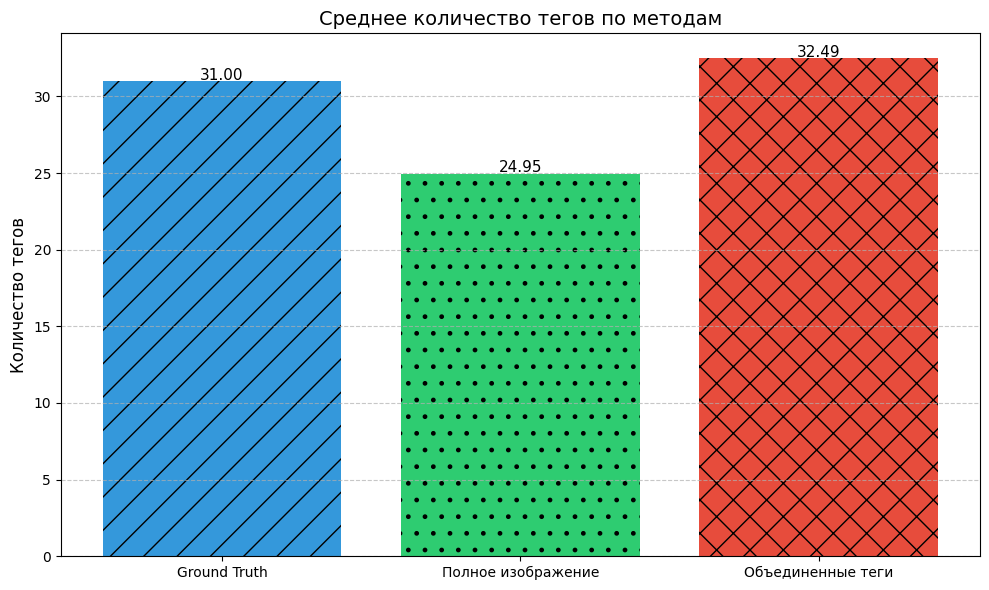

,Precision,Recall,F1-score
Объединенные теги,78.25,87.54,82.64
Полное изображение,81.13,75.01,77.95


Error analysis saved to full_image_errors.csv
Error analysis saved to merged_tags_errors.csv
Tag performance analysis saved to full_image_tag_performance.csv
Tag performance analysis saved to merged_tags_tag_performance.csv


Изображение,F1,Precision,Recall,Кол-во FP,Кол-во FN
test1,0.38,0.76,0.25,7,65
GdjyZ8t,0.42,0.88,0.28,2,39
(65),0.48,0.84,0.34,3,31
test4,0.49,0.84,0.35,3,30
BuyFfGW,0.58,0.66,0.51,10,18


Категория,Теги
Правильные теги,"barefoot, black dress, blonde hair, blush stickers, clone, dress, holding, legs, long hair, long legs, looking at viewer, multiple girls, multiple persona, oshino shinobu, pointy ears, school uniform, shoes, sitting, sitting on stairs, stairs, very long hair, yellow eyes"
Ложноположительные теги,"1girl, age progression, book, doughnut, food, multiple views, smile"
Ложноотрицательные теги,":o, arm at side, arm support, back, bare legs, bare shoulders, between legs, black footwear, black ribbon, black sailor collar, black shirt, black skirt, black socks, black vest, blue skirt, blush, buttons, closed mouth, collarbone, collared shirt, eyelashes, feet, flat chest, flipped hair, frilled skirt, frills, from behind, hand between legs, hand on own chest, hand up, high collar, indoors, knee up, long sleeves, looking back, looking to the side, mary janes, neck ribbon, no socks, open mouth, parted lips, petite, pleated skirt, railing, red ribbon, ribbon, sailor collar, serafuku, shadow, shiny skin, shirt, shirt tucked in, short sleeves, sidelocks, skirt, sleeveless, socks, standing, straight hair, strap slip, swept bangs, toes, v arms, vest, white shirt"


Категория,Теги
Правильные теги,"1boy, 1girl, araragi koyomi, black hair, blonde hair, city, dress, long hair, long legs, oshino shinobu, road, short hair, street, tree, yellow eyes"
Ложноположительные теги,"crosswalk, vanishing point"
Ложноотрицательные теги,"arms at sides, bare arms, bare legs, blush, blush stickers, brown pants, bush, chain, closed mouth, expressionless, flipped hair, from side, full body, grey pants, hair flaps, halter dress, halterneck, hood, hood down, hooded jacket, looking at another, open mouth, outdoors, pants, pointy ears, profile, red bow, road sign, sandals, short sleeves, sleeveless, standing, sundress, surprised, waist bow, white dress, white footwear, white jacket, wide shot"


...

Категория,Теги
Правильные теги,"1boy, 1girl, animal, animal on head, back-to-back, bird, bird on head, black hair, brown eyes, closed eyes, grey hair, indoors, long hair, old, old man, on head, parted lips, short hair, television, wrinkled skin"
Ложноположительные теги,"3:, animal ears, animal nose, body fur, breasts, chicken, food, from side, furry, furry female, hair down, kitashirakawa tamako, old woman, pokemon (creature), rabbit, rabbit ears, rabbit girl, wagashi, white fur, white hair"
Ложноотрицательные теги,"looking back, thick eyebrows"


Категория,Теги
Правильные теги,"blue sky, building, cloud, day, no humans, outdoors, power lines, scenery, tree, utility pole, window"
Ложноположительные теги,"bush, city, cloudy sky, fence, grass, house, lamppost, road, sidewalk, sky, street, town"
Ложноотрицательные теги,Нет


Тег,F1,Precision,Recall,TP,FP,FN,Всего в GT,Всего предсказано
full body,0.00,0.00,0.00,0,0,4,4,0
flipped hair,0.00,0.00,0.00,0,0,6,6,0
looking to the side,0.00,0.00,0.00,0,0,5,5,0
arms at sides,0.40,1.00,0.25,1,0,3,4,1
looking at another,0.40,1.00,0.25,1,0,3,4,1


Тег,Найдено пропущенных тегов,Вхождений в GT,Пропущено (полное),Пропущено (объединенные),Изменение Precision,Изменение Recall,Изменение F1,Precision (полное),Recall (полное),F1 (полное),Precision (объединенные),Recall (объединенные),F1 (объединенные)
open mouth,8.0,13.0,8.0,0.0,+0.00%,+61.54%,+44.44%,100.00%,38.46%,55.56%,100.00%,100.00%,100.00%
black eyes,8.0,10.0,9.0,1.0,+0.00%,+80.00%,+76.56%,100.00%,10.00%,18.18%,100.00%,90.00%,94.74%
profile,7.0,8.0,7.0,0.0,+0.00%,+87.50%,+77.78%,100.00%,12.50%,22.22%,100.00%,100.00%,100.00%
closed mouth,6.0,10.0,7.0,1.0,+0.00%,+60.00%,+48.58%,100.00%,30.00%,46.15%,100.00%,90.00%,94.74%
wrinkled skin,5.0,6.0,6.0,1.0,+100.00%,+83.33%,+90.91%,0.00%,0.00%,0.00%,100.00%,83.33%,90.91%
blush,5.0,8.0,7.0,2.0,+0.00%,+62.50%,+63.49%,100.00%,12.50%,22.22%,100.00%,75.00%,85.71%
pants,4.0,6.0,4.0,0.0,+0.00%,+66.67%,+50.00%,100.00%,33.33%,50.00%,100.00%,100.00%,100.00%
:o,3.0,4.0,3.0,0.0,+0.00%,+75.00%,+60.00%,100.00%,25.00%,40.00%,100.00%,100.00%,100.00%
parted lips,3.0,3.0,3.0,0.0,+100.00%,+100.00%,+100.00%,0.00%,0.00%,0.00%,100.00%,100.00%,100.00%
from behind,3.0,7.0,3.0,0.0,+0.00%,+42.86%,+27.27%,100.00%,57.14%,72.73%,100.00%,100.00%,100.00%


Тег,Добавлено некорректных тегов,Вхождений в GT,Некорректных (полное),Некорректных (объединенные),Изменение Precision,Изменение Recall,Изменение F1,Precision (полное),Recall (полное),F1 (полное),Precision (объединенные),Recall (объединенные),F1 (объединенные)
food,2.0,4.0,1.0,3.0,-22.86%,+0.00%,-16.16%,80.00%,100.00%,88.89%,57.14%,100.00%,72.73%
from side,2.0,7.0,0.0,2.0,-33.33%,+28.57%,+17.09%,100.00%,28.57%,44.44%,66.67%,57.14%,61.54%
mole on neck,2.0,4.0,4.0,6.0,-2.86%,+25.00%,+2.60%,42.86%,75.00%,54.55%,40.00%,100.00%,57.14%
brown eyes,2.0,6.0,0.0,2.0,-25.00%,+0.00%,-14.29%,100.00%,100.00%,100.00%,75.00%,100.00%,85.71%
mole,1.0,3.0,0.0,1.0,-25.00%,+33.33%,+5.71%,100.00%,66.67%,80.00%,75.00%,100.00%,85.71%
expressionless,1.0,4.0,0.0,1.0,-25.00%,+50.00%,+35.00%,100.00%,25.00%,40.00%,75.00%,75.00%,75.00%
cat,1.0,4.0,0.0,1.0,-20.00%,+0.00%,-11.11%,100.00%,100.00%,100.00%,80.00%,100.00%,88.89%
hood,1.0,3.0,0.0,1.0,-33.33%,+33.33%,+16.67%,100.00%,33.33%,50.00%,66.67%,66.67%,66.67%
short hair,1.0,15.0,0.0,1.0,-6.25%,+20.00%,+7.89%,100.00%,80.00%,88.89%,93.75%,100.00%,96.77%
animal ears,1.0,3.0,1.0,2.0,-15.00%,+0.00%,-10.71%,75.00%,100.00%,85.71%,60.00%,100.00%,75.00%


In [7]:
from Scripts import compare_tagging_methods
data=compare_tagging_methods(
    image_folder=  PATH_TO_DATASET,
    txt_folder=  PATH_TO_DATASET,
    results=result,
    model_labels_path="./models/taggers/wd-eva02-large-tagger-v3/selected_tags.csv",
    filter_tags=True,
    num_worst_examples=5,
    visualize=True,
    interactive=True
)

In [8]:
data[1]

{'Полное изображение':       image                                  ground_truth_tags  \
 33    test1  :o, arm at side, arm support, back, bare legs,...   
 8   GdjyZ8t  1boy, 1girl, araragi koyomi, arms at sides, ba...   
 36     (65)  1boy, 2girls, backpack, bag, black eyes, black...   
 4     test4  1boy, 1girl, ahoge, araragi koyomi, back, blac...   
 32  BuyFfGW  1boy, 1girl, ahoge, araragi koyomi, arms at si...   
 1   0SxBXLP  1girl, barefoot, blonde hair, bloom, crack, da...   
 0   aPnYnbG  blue sky, building, cloud, day, no humans, out...   
 20  amlEGsC  animal, building, cat, dark, from below, house...   
 16     (60)      door, indoors, no humans, scenery, still life   
 21    test3  6+girls, :<, :d, androgynous, black eyes, blac...   
 25  frvxt83  1girl, arms at sides, bare arms, bare legs, ba...   
 22     (48)  1boy, 1girl, bird, black eyes, black hair, blu...   
 18     (57)  1boy, 2girls, aged down, animal, animal on hea...   
 28     (54)  1boy, 1girl, :o, age diffe